# 11 优化算法

优化和深度学习的目标不同，前者关注最小化目标，后者关注在给定有限数据量的情况下寻找合适的模型。优化的目标是减少训练误差，而深度学习使用优化算法减少训练误差之外，还要防止过拟合。

这一章中许多内容在课程 《线性优化与凸优化》 中已经提及。对于已涉及的数学概念，将只提及其特殊名词。

**局部最小值，鞍点，梯度消失，凸性**

##### 约束
采用拉格朗日函数 $L$ 可以近似地满足约束优化问题，即将约束条件添加入目标函数。 **惩罚** 如 $L_2$ 正则化即是这种数学原理。
##### 投影
《面向人工智能的线性代数》课程中的最小二乘法部分。这也可以近似地满足优化约束。

**梯度下降**

##### 牛顿法的预处理
原本的牛顿法：
$$\mathbf{x}_{k+1} = \mathbf{x}_{k} - \eta\mathbf{H}_k^{-1}\nabla f(\mathbf{x}_k)$$
引入线性变换预处理 $\mathbf{x} = \mathbf{Pz}$ ，得新 Hessian 矩阵为：
$$\mathbf{H}^* = \mathbf{P}^T \nabla^2 f(\mathbf{x}) \mathbf{P}$$
新梯度更新公式为：
$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \eta\mathbf{P} \left[ \mathbf{P}^\top \mathbf{H} \mathbf{P} \right]^{-1} \mathbf{P}^\top \nabla f(\mathbf{x}_k)
$$
设置 $\mathbf{P}^T\mathbf{P} \approx \mathbf{H}^{-1}$ ，使得 $\mathbf{P}^T\mathbf{HP} \approx \mathbf{I}$ 。
常见的预处理矩阵包括对角预处理（Jacobi预处理）：取P为对角矩阵，其元素为Hessian矩阵对角线元素的平方根的倒数（即 $\mathbf{P}_{ii} = \frac{1}{\sqrt{\mathbf{H}_{ii}}}$ ） 。这种预处理可以使不同数量级的数据降至同一数量级，学习率的设置将更为有效。

**线搜索**





## 1 随机梯度下降

在随机梯度下降的每次迭代中，对数据样本随机均匀采样一个索引 $i$ ，其中 $i \in {1,...,n}$ ，使用其梯度 $\nabla f_i(\mathbf{x})$ 作为 $\nabla f(\mathbf{x}) = \frac{1}{n}\sum_{i=1}^n \nabla f_i(\mathbf{x})$ 的无偏估计。

$$
\mathbf{x} \leftarrow \mathbf{x} - \eta\nabla f_i(\mathbf{x})
$$

虽然无偏，但是集中性（方差）不如原来，因此在接近最小值时会受到不确定性的影响，此时需要降低学习率。换句话说，学习率将是动态变化的。



#### 动态学习率


基本的动态学习率策略：

1. **分段常数（piecewise constant）** ：$$\eta(t) = \eta_i \text{ if } t_i \leq t \leq t_{i+1}$$
2. **指数衰减（exponential decay）** ：$$\eta(t) = \eta_0 \cdot e^{-\lambda t}$$ 。通常该算法根本无法收敛。
3. **多项式衰减（polynomial decay）** ：$$\eta(t) = \eta_0 \cdot (\beta t + 1)^{-\alpha}$$



## 2 小批量随机梯度下降

在 11.1 中讲到，随机梯度下降集中性差，而小批量随机梯度下降则是对此的改进：

$$
\mathbf{g}_t = \partial_{\mathbf{w}} \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} f(\mathbf{x}_i, \mathbf{w})
$$

小批量随机梯度下降的整体步骤是：

1. 初始化模型参数（例如权重和偏置）
2. 设置超参数（如学习率 `η` ，批量大小 `batch_size` ，迭代次数 `epochs`）。
3. 对于每个 `epoch` ： 
    1. 随机打乱训练数据集。
    2. 将打乱后的数据集划分为多个小批量（每个小批量包含 `batch_size` 个样本，最后一个可能不足则用剩余样本）。
    3. 对于每个小批量：
        1. 计算小批量上的损失函数（前向传播）
        2. 计算损失函数关于参数的梯度（反向传播）。
        3. 更新参数：$θ = θ - η * \text{梯度}$

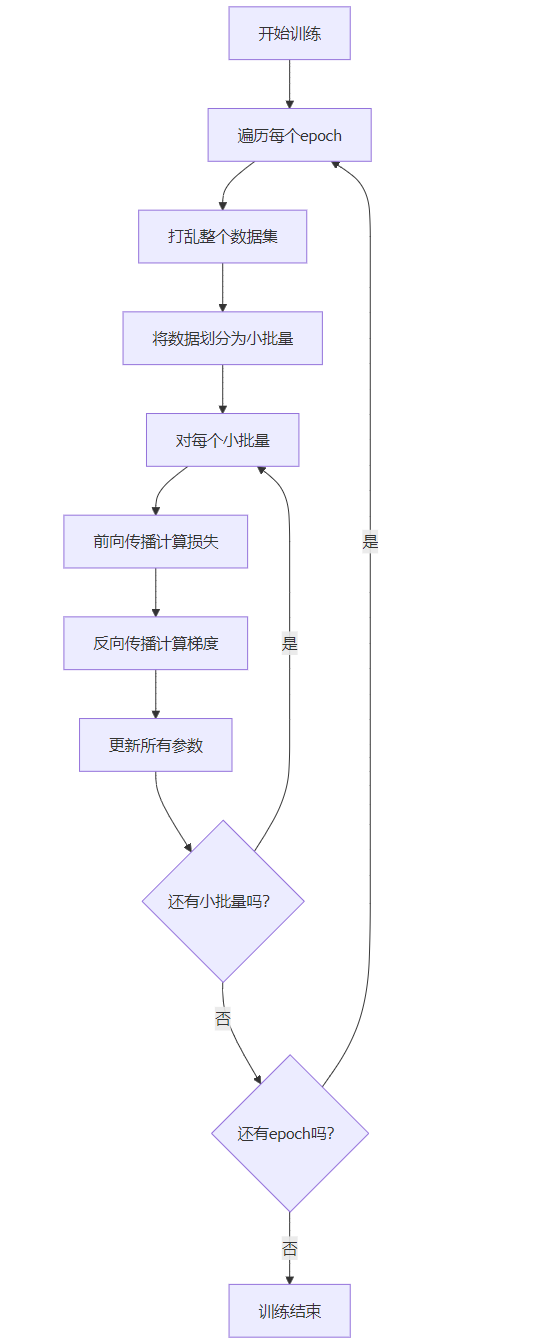

虽然看上去没有减少实际运算量，但是实际上是运用了现代硬件的并行计算能力，从而减小了实际运行时间。

## 3 动量法

#### 泄露平均值

**动量（momentum）** ，累积了过去的梯度。若以符号 $\mathbf{v}$ 记，其计算为：

$$
\mathbf{v}_t = \beta\mathbf{v}_{t-1} + \mathbf{g}_{t,t-1} = 
\mathbf{v}_t = \beta^2 \mathbf{v}_{t-2} + \beta \mathbf{g}_{t-1,t-2} + \mathbf{g}_{t,t-1} = \dots = \sum_{\tau=0}^{t-1} \beta^\tau \mathbf{g}_{t-\tau, t-\tau-1}.
$$

其中：

$$
\mathbf{g}_{t,t-1} = \partial_{\mathbf{w}} \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} f(\mathbf{x}_i, \mathbf{w}_{t-1}) = \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} \mathbf{h}_{i,t-1}.
$$

1. 较大的 $\beta$ 相当于长期平均值，而较小的 $\beta$ 相对于梯度法只是略有修正
2. 新的梯度替换不再指向特定实例下降最陡的方向，而是指向过去梯度的加权平均值的方向

在某些情况下，有些方向非常平坦，有些方向变化非常剧烈。振荡反映为反复横跳，而平坦在振荡的影响下反映为企鹅前进。使用动量法能 **在平坦方向上聚合梯度，增加这个方向上前进的距离**， **在振荡方向上，相互抵消振荡，减小这个方向上前进的距离** 。总的来说，它能 **防止在随机梯度下降的优化过程停滞的问题** 。

## 4 AdaGrad算法

使用全局统一的学习率衰减，如 $\eta = \frac{\eta_0}{\sqrt{t+c}}$ ，会出现以下问题：

- 若学习率衰减过快：常见词的参数会快速收敛到最优值，但罕见词因为更新次数太少，还没学到最优，学习率就已经降到几乎为 0
- 若学习率衰减过慢：罕见词能充分学习，但常见词因为更新频繁、学习率过高，导致参数震荡，无法收敛

这时需要 **给不同参数分配独立的学习率** 。



一个简单的解决方案是用计数器 $s(i,t)$ 记录特征 $i$ 截至 $t$ 步的出现次数，给每个参数分配独立学习率：

$$
\eta_i = \frac{\eta_0}{\sqrt{s(i,t)+c}}
$$



出现次数是一个具有缺陷的统计量，因为学习率大小应当关注的是梯度的大小。 AdaGrad 将计数器 $s(i,t)$ 替换为 **截至当前步，参数 $i$ 的所有历史梯度的平方和** 。

对于第 $t$ 步，参数 $i$ 的累积量：

$$
s^{(t)}_i = s^{(t-1)}_i + (g^{(t)}_i)^2
$$

为了方便理解，我将剖析该算法的代码：

```bash
def adagrad(params, states, hyperparams):
    eps = 1e-6                          #eps即是公式中的c，为了防止分母为0的极小值
    for p, s in zip(params, states):    
        with torch.no_grad():           #关闭梯度追踪（参数更新不需要计算梯度）
            # 1. 累加当前参数的梯度平方到s中（每个参数独立累加）
            s[:] += torch.square(p.grad)
            # 2. 核心：参数更新 = 基准学习率 × 梯度 / 该参数的梯度平方和平方根
            p[:] -= hyperparams['lr'] * p.grad / torch.sqrt(s + eps)
        # 3. 清零当前参数的梯度，准备下一次迭代 
        p.grad.data.zero_()
```

也就是说，给每个参数分配不同学习率的核心是 **利用了 `torch` 中张量逐元素运算的特性** 。




## 5 RMSProp算法

AdaGrad 算法将梯度 $\mathbf{g}_t$ 的平方累加成状态矢量 $\mathbf{s}_t = \mathbf{s}_{t-1} + \mathbf{g}_t^2$ ，由于缺乏规范化， $\mathbf{s}_t$ 持续增长且大部分时候线性递增。

使用 11.3 中动量法提到的泄露平均值，能够解决这个问题：

$$
\mathbf{s}_t \leftarrow \gamma\mathbf{s}_{t-1} + (1-\gamma)\mathbf{g}_t^2
$$

$$
\mathbf{x}_t \leftarrow \mathbf{x}_{t-1} - \frac{\eta}{\sqrt{\mathbf{s}_t+\epsilon}} \odot \mathbf{g}_t
$$

1. 互补系数 $1-\gamma$ ：

    本质上希望实现 $\frac{\mathbf{s}_t}{t}$ ，互补系数可以保证历史梯度平方的权重和为1，让 $\mathbf{s}_t$ 真正代表“近期梯度平方的平均值”，实现AdaGrad中没有的规范化。

    而 11.3 中的泄露平均值没有互补系数，是因为它是对优化方向的处理，这里是对学习率的处理。动量法需要寻找的是优化的“惯性”。

2. AdaGrad 线性递增的原因：

    随机梯度场景下，梯度不等于真实梯度，始终有噪声。





## 6 Adadelta

AdaGrad 算法通过累积梯度为每个参数分配不同的学习率：

$$
s^{(t)}_i = s^{(t-1)}_i + (g^{(t)}_i)^2
$$

$$
\eta_i = \frac{\eta_0}{\sqrt{s^{(t)}_i+c}}
$$

RMSGrop 算法使用互补系数将梯度平方的累积规范化：

$$
\mathbf{s}_t = \rho\mathbf{s}_{t-1} + (1-\rho)\mathbf{g}_t^2
$$

Adadelta 算法使用新的量 $\Delta \mathbf{x}_t$ 记录参数变化的平均幅度，让当前步长和历史更新幅度保持一致：

$$
\Delta \mathbf{x}_t = \rho \Delta \mathbf{x}_{t-1} + (1-\rho) \mathbf{g}_t'^2
$$

其中：

$$
\mathbf{g}_t' = \frac{\sqrt{\Delta \mathbf{x}_{t-1}+c}}{\sqrt{\mathbf{s}_t + c}} \odot \mathbf{g}_t
$$

总而言之：

$$
\eta_0 \rightarrow \sqrt{\Delta \mathbf{x}_{t-1}+c} = \sqrt{\overline{\mathbf{g}'_{i}}+c} 
$$

这样不仅继承了AdaGrad 算法自适应步长的优点，而且没有了全局学习率，用历史参数变化自动校准步长。

## 7 Adam算法

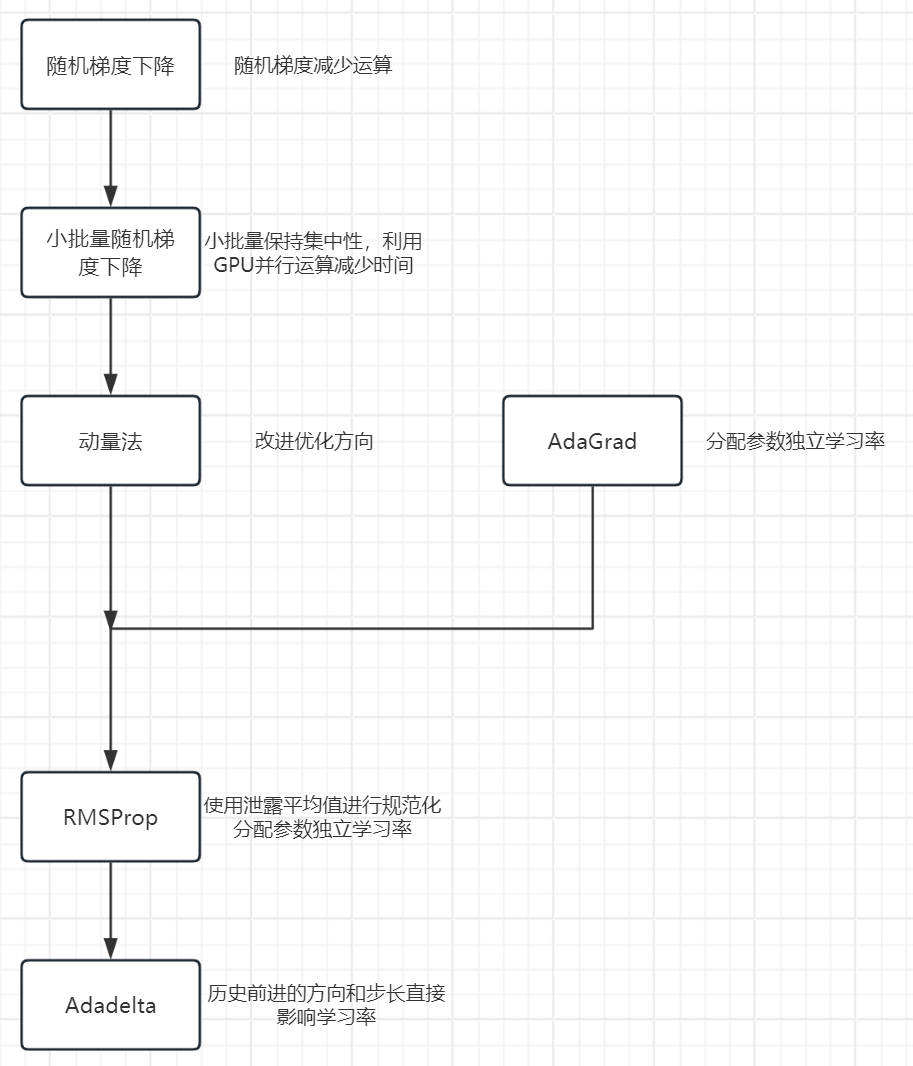

上面的图总结了前面的算法在优化性能上的贡献。**Adam 算法综合了动量法在优化方向上和 RMSProp 算法在规范化的独立学习率上的优点** ：

1. 动量法部分：
$$
\mathbf{v}_t \leftarrow \beta_1 \mathbf{v}_{t-1} + (1-\beta_1)\mathbf{g}_t
$$
$$
\hat{\mathbf{v}_t} = \frac{\mathbf{v}_t}{1-\beta_1^t}
$$

2. RMSProp 算法部分：
$$
\mathbf{s}_t \leftarrow \beta_2 \mathbf{s}_{t-1} + (1-\beta_2)\mathbf{g}_t^2
$$
$$
\hat{\mathbf{s}_t} = \frac{\mathbf{s}_t}{1-\beta_2^t}
$$
$$
\eta_t \leftarrow \frac{\eta}{\sqrt{\hat{\mathbf{s}_t}}+c}
$$

注意：

- $\hat{\mathbf{v}_t}$ 和 $\hat{\mathbf{s}_t}$ 的得出是为了解决 $\mathbf{v}_0 = \mathbf{s}_0 = 0$ 的初始偏差问题。
- 学习率使用 $\frac{1}{\sqrt{\hat{\mathbf{s}_t}}+c}$ 而不是 $\frac{1}{\sqrt{\hat{\mathbf{s}_t}+c}}$ 进行缩放。



因此，更新公式为：

$$
\mathbf{x}_t \leftarrow \mathbf{x}_{t-1} - \frac{\eta}{\sqrt{\hat{\mathbf{s}_t}}+c} \odot \hat{\mathbf{v}_t}
$$

#### Yogi

$$\mathbf{s}_t \leftarrow \mathbf{s}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2 \odot \operatorname{sgn}(\mathbf{g}_t^2 - \mathbf{s}_{t-1})$$

公式通过 $\operatorname{sgn}(\mathbf{g}_t^2 - \mathbf{s}_{t-1})$ 构建了一个 **残差反馈项** ：

- 当当前梯度平方 $\mathbf{g}_t^2$ 大于历史状态 $\mathbf{s}_{t-1}$ 时，符号为正，**正向增强**状态更新
- 当 $\mathbf{g}_t^2$ 小于 $\mathbf{s}_{t-1}$ 时，符号为负，**反向抑制**状态增长

Yogi 解决了 $\mathbf{s}_t$ 的二次矩估计值爆炸问题和 $\mathbf{g}_t^2$ 很大或很小的情况。

## 8 学习率调度器

在 11.1 中介绍了动态学习率。 **学习率调度器（learning rate scheduler）** 即是一个基于动态学习率如何生成的调用的工具。

1. **单因子调度器** ：

$$
\eta_{t+1} \leftarrow \max (\eta_{min}, \eta_t \cdot \alpha)
$$

2. **多因子调度器** ：

给定一组降低学习率的时间点，例如 $s = {5,10,20}$ ，每当 $t \in s$ 时，降低 $\eta_{t+1} \rightarrow \eta_{t} \cdot \alpha$ 。

3. **余弦调度器** ：

不想一开始学习率下降太快，而且希望最终能用非常小的学习率，类似余弦。
$$
\eta_t = \eta_T + \frac{\eta_0 - \eta_T}{2}\left(1 + \cos\left(\frac{\pi t}{T}\right)\right)
$$
对于 $t > T$ ，只需将值固定到 $\eta_T$ 而不再增加它。


#### 预热



训练初期，不让学习率直接拉满，而是 **从很小慢慢平滑升到设定的初始学习率** 。

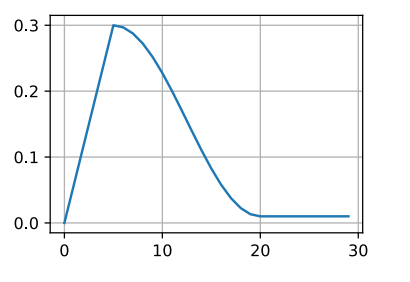

#### Pytorch中的调度器

较教材新增对 Pytorch 中封装好的基础调度器的了解：

```python
from torch.optim.lr_scheduler import (
    StepLR,          # 阶梯式衰减
    CosineAnnealingLR, # 余弦退火（最常用）
    ExponentialLR,   # 指数衰减
    LinearLR         # 线性调度（用于预热）
)
```

```python
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
```

```python
scheduler = CosineAnnealingLR(optimizer, T_max=100)
```
